# Single Dithering Exporter & Parameter Tuner
Select an algorithm (`direct`, `bayer`, `floyd`), adjust parameters, and export the resulting 1-bit image to a file.

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess(image_path: str, max_size: int = 1024, invert: bool = True) -> np.ndarray:
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image at path: {image_path}")
    h, w = img.shape
    if max(h, w) > max_size:
        scale = max_size / float(max(h, w))
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    img_float = img.astype(np.float32) / 255.0

    if invert:
            img_float = 1.0 - img_float
    return img_float

def direct_threshold(image: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    return (image >= threshold).astype(np.float32)

def ordered_dither_bayer(image: np.ndarray, matrix_size: int = 4) -> np.ndarray:
    if matrix_size == 2:
        bayer = (1.0 / 4.0) * np.array([[0, 2], [3, 1]], dtype=np.float32)
    elif matrix_size == 4:
        bayer = (1.0 / 16.0) * np.array([
            [ 0,  8,  2, 10],
            [12,  4, 14,  6],
            [ 3, 11,  1,  9],
            [15,  7, 13,  5]
        ], dtype=np.float32)
    elif matrix_size == 8:
        bayer_4 = np.array([
            [ 0,  8,  2, 10],
            [12,  4, 14,  6],
            [ 3, 11,  1,  9],
            [15,  7, 13,  5]
        ], dtype=np.float32)
        bayer = (1.0 / 64.0) * np.block([
            [4 * bayer_4,     4 * bayer_4 + 2],
            [4 * bayer_4 + 3, 4 * bayer_4 + 1]
        ])
    elif matrix_size == 16:
        bayer_4 = np.array([
            [ 0,  8,  2, 10],
            [12,  4, 14,  6],
            [ 3, 11,  1,  9],
            [15,  7, 13,  5]
        ], dtype=np.float32)
        bayer_8 = np.block([
            [4 * bayer_4,     4 * bayer_4 + 2],
            [4 * bayer_4 + 3, 4 * bayer_4 + 1]
        ])
        bayer = (1.0 / 255.0) * np.block([
            [4 * bayer_8,     4 * bayer_8 + 2],
            [4 * bayer_8 + 3, 4 * bayer_8 + 1]
        ])
    else:
        raise ValueError("Supported matrix sizes are 2, 4, or 8.")
    h, w = image.shape
    tiled_matrix = np.tile(bayer, (h // matrix_size + 1, w // matrix_size + 1))[:h, :w]
    return (image > tiled_matrix).astype(np.float32)

def floyd_steinberg_dither(image: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    img = image.copy().astype(np.float32)
    h, w = img.shape
    for y in range(h):
        for x in range(w):
            old_val = img[y, x]
            new_val = 1.0 if old_val >= threshold else 0.0
            img[y, x] = new_val
            err = old_val - new_val
            if x + 1 < w:
                img[y, x + 1] += err * (7.0 / 16.0)
            if x - 1 >= 0 and y + 1 < h:
                img[y + 1, x - 1] += err * (3.0 / 16.0)
            if y + 1 < h:
                img[y + 1, x] += err * (5.0 / 16.0)
            if x + 1 < w and y + 1 < h:
                img[y + 1, x + 1] += err * (1.0 / 16.0)
    return img

Exported to: output_dithered.png (Inverted Output = True)


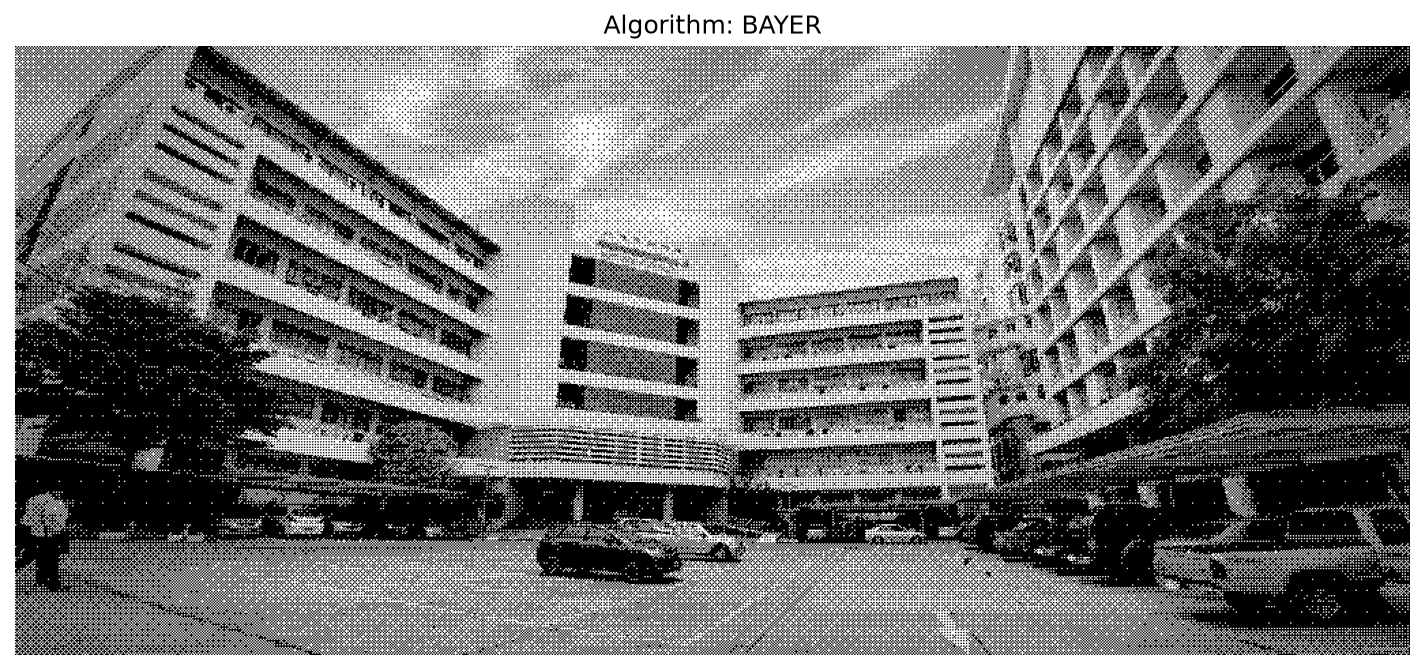

In [39]:
INPUT_FILE = "building_0d928c59b5.jpg"
OUTPUT_FILE = "output_dithered.png"

ALGORITHM_CHOICE = "bayer"  # Options: "direct", "bayer", or "floyd"
THRESHOLD_VAL = 0.5        # Threshold cutoff [0.0 to 1.0]
BAYER_SIZE = 16             # Bayer matrix size (2, 4, or 8)

# SET THIS TO TRUE TO FLIP BLACK/WHITE OUTPUT
INVERT_OUTPUT = True

# Pipeline Execution
img = load_and_preprocess(INPUT_FILE)

if ALGORITHM_CHOICE == "direct":
    out = direct_threshold(img, threshold=THRESHOLD_VAL)
elif ALGORITHM_CHOICE == "bayer":
    out = ordered_dither_bayer(img, matrix_size=BAYER_SIZE)
elif ALGORITHM_CHOICE == "floyd":
    out = floyd_steinberg_dither(img, threshold=THRESHOLD_VAL)

# Invert 1-bit binary output if set
if INVERT_OUTPUT:
    out = 1.0 - out

# Save output
export_img = (out * 255.0).astype(np.uint8)
cv2.imwrite(OUTPUT_FILE, export_img)
print(f"Exported to: {OUTPUT_FILE} (Inverted Output = {INVERT_OUTPUT})")

# Preview output
plt.figure(figsize=(12, 12), dpi=150)
plt.imshow(out, cmap='gray')
plt.title(f"Algorithm: {ALGORITHM_CHOICE.upper()}")
plt.axis('off')
plt.show()

Saved: zoom_10x10.png
Saved: zoom_50x50.png
Saved: zoom_200x200.png
Saved: full_1000x1000.png
Saved combined comparison figure: hvs_optical_blending_comparison.png


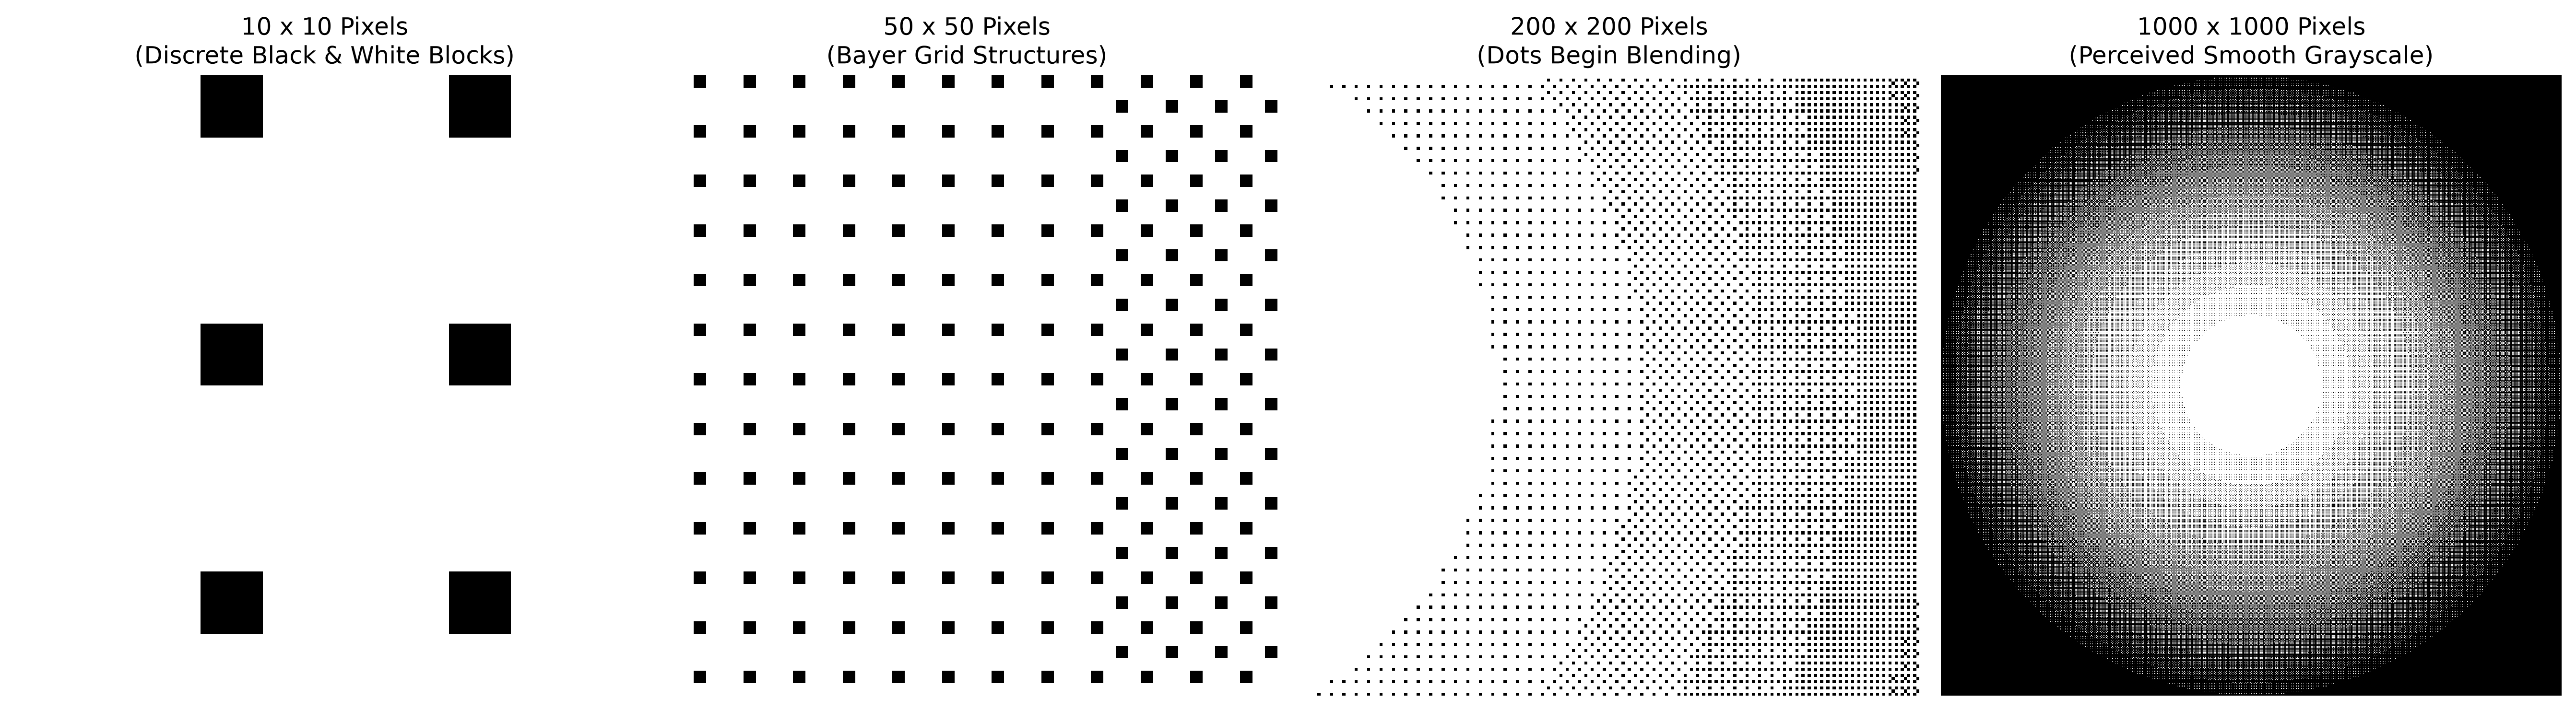

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def generate_dithered_sphere(size=1000):
    """Generates a high-resolution dithered sphere image."""
    y, x = np.ogrid[-1:1:complex(0, size), -1:1:complex(0, size)]
    radius = np.sqrt(x**2 + y**2)
    sphere = np.cos(radius * np.pi / 2)
    sphere[radius > 1] = 0
    sphere = np.clip(sphere, 0, 1).astype(np.float32)

    # Apply 4x4 Bayer Dithering
    bayer_4x4 = (1.0 / 16.0) * np.array([
        [ 0,  8,  2, 10],
        [12,  4, 14,  6],
        [ 3, 11,  1,  9],
        [15,  7, 13,  5]
    ], dtype=np.float32)

    tiled_matrix = np.tile(bayer_4x4, (size // 4 + 1, size // 4 + 1))[:size, :size]
    return (sphere > tiled_matrix).astype(np.float32)

def save_image_nearest(image_array: np.ndarray, filename: str, scale_factor: int = 1):
    """Saves a binary floating-point matrix as a PNG using nearest-neighbor scaling."""
    img_uint8 = (image_array * 255.0).astype(np.uint8)

    # Scale up small pixel grids using nearest-neighbor interpolation so they aren't tiny files
    if scale_factor > 1:
        h, w = img_uint8.shape
        img_uint8 = cv2.resize(img_uint8, (w * scale_factor, h * scale_factor), interpolation=cv2.INTER_NEAREST)

    cv2.imwrite(filename, img_uint8)
    print(f"Saved: {filename}")

# 1. Generate 1000x1000 base dithered image
full_image = generate_dithered_sphere(size=1000)

# 2. Extract zoomed regions centered on the sphere gradient boundary
center_y, center_x = 500, 650

zoom_10x10   = full_image[center_y - 5:center_y + 5, center_x - 5:center_x + 5]
zoom_50x50   = full_image[center_y - 25:center_y + 25, center_x - 25:center_x + 25]
zoom_200x200 = full_image[center_y - 100:center_y + 100, center_x - 100:center_x + 100]

# 3. Export individual image files (upscaled with nearest neighbor so pixel edges stay sharp)
save_image_nearest(zoom_10x10, "zoom_10x10.png", scale_factor=40)     # Upscaled to 400x400 for presentation clarity
save_image_nearest(zoom_50x50, "zoom_50x50.png", scale_factor=8)       # Upscaled to 400x400
save_image_nearest(zoom_200x200, "zoom_200x200.png", scale_factor=2)   # Upscaled to 400x400
save_image_nearest(full_image, "full_1000x1000.png", scale_factor=1)   # Native 1000x1000 resolution

# 4. Export combined comparison banner for presentation slides
fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=300)

axes[0].imshow(zoom_10x10, cmap='gray', interpolation='nearest')
axes[0].set_title("10 x 10 Pixels\n(Discrete Black & White Blocks)")

axes[1].imshow(zoom_50x50, cmap='gray', interpolation='nearest')
axes[1].set_title("50 x 50 Pixels\n(Bayer Grid Structures)")

axes[2].imshow(zoom_200x200, cmap='gray', interpolation='nearest')
axes[2].set_title("200 x 200 Pixels\n(Dots Begin Blending)")

axes[3].imshow(full_image, cmap='gray', interpolation='nearest')
axes[3].set_title("1000 x 1000 Pixels\n(Perceived Smooth Grayscale)")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig("hvs_optical_blending_comparison.png", bbox_inches='tight')
print("Saved combined comparison figure: hvs_optical_blending_comparison.png")
plt.show()